# Causal methods for time series

"Ice cream sales cause drownings" is the canonical warning about confusing correlation with causation. With time series the trap is deeper: two series can march together for decades, produce a regression with an R² of 0.95, and share *no relationship at all* beyond the fact that both drift with time. Yet time also gives us something cross-sectional data never can — **a cause must precede its effect** — and an entire family of methods has been built to exploit that arrow.

This notebook climbs that family as a ladder, each rung answering a question the previous rung could not, using **one real dataset throughout**: fifty years of quarterly US macroeconomic data (1959–2009). No simulations — every result below is the economy talking, which also means the answers come with real-world mess we will not hide.

The ladder:

1. **Vector Autoregression (VAR)** — model several series *jointly*; does the system beat a collection of single-series models?
2. **Granger causality** — does the past of one series carry unique information about the future of another? Bivariate first, then conditional, then the multiple-testing correction that keeps us honest.
3. **Cointegration** (Engle–Granger, Johansen) — when series are non-stationary, naive level regressions become *spurious*; cointegration is the disciplined way to ask whether trending series share a genuine long-run equilibrium.
4. **Vector Error Correction (VECM)** — the model you fit once cointegration is established: short-run dynamics tethered to the long-run relation.
5. **Toda–Yamamoto** — causality testing that stays valid when you *don't know* the integration/cointegration status — which, as our own results will show, is the usual situation.
6. **Structural VAR (SVAR)** — from lagged prediction to *contemporaneous* causal structure, impulse responses, and the price of identifying assumptions.

One caveat up front, worth repeating at every rung: these methods detect **predictive precedence**, not manipulative causality. "X Granger-causes Y" means X's past improves forecasts of Y — a statement about information, not about what happens if you *intervene* on X. Granger himself preferred "temporally related". We will use the standard terminology, but the philosophical asterisk applies throughout.

# Setup

Imports first, grouped as always: standard library, then core data tools, then the modeling stack, then configuration.

In [1]:
# Standard library imports
import warnings
import io
import contextlib

# Third-party imports - core data -> modeling -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# statsmodels: the engine room for everything in this notebook
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_coint_rank, VECM
from statsmodels.datasets import macrodata

from scipy import stats

# Configuration & settings
warnings.simplefilter(action="ignore")            # silence convergence/deprecation chatter

A few words on each group, since the whole notebook rests on this cell.

The **standard library** trio is unglamorous but load-bearing: `warnings` silences the deprecation and interpolation chatter that statsmodels emits (noise for our purposes — we suppress it once, globally); `io` and `contextlib` are used together in one helper below to *capture and discard* the verbose report that `grangercausalitytests` insists on printing, keeping our output readable.

**`numpy`** (`np`) supplies array math and the log/diff transforms; **`pandas`** (`pd`) holds every dataset in labeled `DataFrame`s; **`matplotlib.pyplot`** (`plt`) draws the figures; **`statsmodels.api`** (`sm`) gives us plain OLS for the spurious-regression demonstration.

The `statsmodels.tsa` block is the toolkit this episode lives in. **`AutoReg`** fits a single-equation autoregression — our simplest baseline. **`VAR`** fits the full multivariate system and, once fitted, also provides Granger tests, impulse responses, and variance decompositions. From `stattools` we take the two unit-root tests (**`adfuller`**, **`kpss`**), the bivariate Granger battery (**`grangercausalitytests`**), and the Engle–Granger cointegration test (**`coint`**). From the `vecm` module: **`coint_johansen`** (the raw Johansen eigenvalue machinery), **`select_coint_rank`** (its tidy rank-selection wrapper), and **`VECM`** itself. Finally, **`macrodata`** is the real dataset we use throughout, and `scipy.stats` supplies the chi-squared distribution for the one test statsmodels does not ship ready-made — Toda–Yamamoto — which we will build by hand.

In [2]:
# general settings
class CFG:
    img_dim1 = 14          # default figure width
    img_dim2 = 6           # default figure height
    SEED     = 42          # global seed for reproducibility
    signif   = 0.05        # significance level used across all tests
    maxlags  = 8           # maximum lag order considered by selection criteria
    horizon  = 20          # forecast hold-out: 20 quarters = 5 years

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

The `CFG` idiom — a bare class used purely as a namespace for constants — recurs in every notebook of this series. Nothing is instantiated; it simply gives every tunable number one home and one name, so no magic numbers float around the body of the notebook.

Two constants deserve a comment. **`signif = 0.05`** is the significance threshold used by *every* hypothesis test below — unit roots, Granger tests, cointegration ranks — so that when a verdict changes, it is because the evidence changed, not the yardstick. **`maxlags = 8`** caps the lag orders our selection criteria may consider: eight quarters = two years of history, a generous ceiling for quarterly macro data.

The style block fixes the plotting theme and default figure size, and `np.random.seed` pins NumPy's global generator. This notebook is almost entirely deterministic — real data, closed-form estimators — but pinning the seed is a reflex worth keeping.

# Utils

Anything we do more than twice becomes a small, well-named helper here, so the body cells below read as short declarative calls. Six helpers: an error metric, a stationarity report, a chronological splitter, a plot wrapper, and clean wrappers around the two causality tests we call repeatedly.

In [3]:
def forecast_metrics(actual, predicted):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = float(np.round(np.mean(np.abs(actual - predicted)), 4))
    rmse = float(np.round(np.sqrt(np.mean((actual - predicted) ** 2)), 4))
    return {"MAE": mae, "RMSE": rmse}

`forecast_metrics` coerces both inputs to float arrays with `np.asarray` (so it accepts Series or plain lists alike) and returns the two workhorse error measures. **MAE** — mean absolute error — is the typical miss in the series' own units. **RMSE** squares before averaging, so large misses are punished disproportionately; it is the metric we use for model comparisons. Both are rounded and cast to plain `float` so result tables print cleanly. Lower is better.

In [4]:
def run_stationarity(df, signif=CFG.signif):
    """Tidy ADF + KPSS report for every column. The two tests have OPPOSITE nulls."""
    rows = []
    for c in df.columns:
        s = df[c].dropna()                                   # both tests choke on NaNs
        adf_p = adfuller(s)[1]                                # H0: unit root (non-stationary)
        kpss_p = kpss(s, regression="c", nlags="auto")[1]     # H0: stationary
        rows.append({
            "series": c,
            "ADF p": round(adf_p, 3),
            "ADF -> stationary?": adf_p < signif,
            "KPSS p": round(kpss_p, 3),
            "KPSS -> stationary?": kpss_p > signif,
        })
    return pd.DataFrame(rows).set_index("series")

Every method in this notebook begins with the same question — *is this series stationary?* — so we make the answer a one-liner. `run_stationarity` runs two complementary unit-root tests on every column and returns a tidy verdict table.

The design point worth internalizing: **the two tests have opposite null hypotheses**. The **Augmented Dickey–Fuller (ADF)** test's null is "there *is* a unit root" — a small p-value rejects non-stationarity, i.e. argues the series is stationary. The **KPSS** test is the mirror image: its null is "the series *is* stationary" — a small p-value argues *against* stationarity. Running both is cheap insurance: when they agree (ADF rejects, KPSS doesn't) the verdict is solid; when they disagree, the series is telling you it sits near the boundary, and you should hold the conclusion loosely. Note the `dropna()` before each test — this is important, as neither test can handle missing values, and differencing (which we do a lot below) always manufactures a leading NaN.

In [5]:
def train_valid_split(df, cutoff):
    """Chronological split. `cutoff` is positional; negative counts from the end."""
    return df.iloc[:cutoff].copy(), df.iloc[cutoff:].copy()

One line, but it encodes the rule this series never breaks (see the validation-methods notebook for the full autopsy of why): **splits are chronological, never random**. The earlier block trains, the later block validates, mimicking the only split reality ever performs. `cutoff` is positional, so `-20` means "hold out the last 20 quarters"; the `.copy()` calls give back independent frames we can safely add forecast columns to.

In [6]:
def plot_multi(df, title, ylabel=""):
    """Consistent multi-series line plot: observed series as solid lines, lw=2."""
    ax = df.plot(linewidth=2, xlabel="")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    plt.legend(loc="best")
    plt.show()

`plot_multi` is the standard wrapper for drawing several series at once — pandas' own `.plot()` (which handles the `PeriodIndex` time axis for us) with the series-wide conventions applied: solid lines, `linewidth=2`, a title, a legend. Using one wrapper everywhere keeps every figure in the notebook visually comparable.

In [7]:
def granger_pvalue(df, cause, effect, maxlag):
    """Bivariate Granger test: 'does `cause` help predict `effect`?'.

    Returns the SSR-based F-test p-value at each lag 1..maxlag.
    statsmodels prints a long report by default; we capture and discard it.
    """
    with contextlib.redirect_stdout(io.StringIO()):
        out = grangercausalitytests(df[[effect, cause]], maxlag=maxlag)
    return {lag: float(np.round(out[lag][0]["ssr_ftest"][1], 4)) for lag in out}

`granger_pvalue` wraps statsmodels' `grangercausalitytests` with two practical wrinkles handled. First — and this is a classic gotcha — **column order matters**: the function always tests whether the *second* column Granger-causes the *first*, so we pass `df[[effect, cause]]` and expose sane keyword names instead of making every caller remember the convention. Second, the function prints a four-test report for every lag; the `contextlib.redirect_stdout(io.StringIO())` construction runs it silently and we keep only the **SSR-based F-test** p-value per lag — the textbook statistic: compare the restricted regression (effect on its own lags) against the unrestricted one (add the cause's lags) and F-test whether the added lags jointly matter.

Returning the p-value *at every lag* from 1 to `maxlag`, rather than one number, is deliberate: as we will see on real data, Granger verdicts can be uncomfortably sensitive to the lag choice, and the honest report is the whole profile.

In [8]:
def toda_yamamoto(df, cause, effect, p, d_max, signif=CFG.signif):
    """Toda-Yamamoto Granger non-causality test; valid for I(0), I(1), or cointegrated data.

    Fit a LEVELS VAR of order (p + d_max); Wald-test ONLY the first p lags of `cause`
    in the `effect` equation, leaving the d_max augmenting lags unrestricted.
    """
    cols = list(df.columns)
    res = VAR(df).fit(p + d_max, trend="c")          # intentionally over-parameterized
    names = list(res.params.index)                   # const, L1.x1, L1.x2, ...
    b = res.params[effect].values                    # coefficients of the effect equation
    nparams = len(names)

    # covariance block belonging to the effect equation
    eff = cols.index(effect)
    V_full = res.cov_params().values
    V = V_full[eff * nparams:(eff + 1) * nparams,
               eff * nparams:(eff + 1) * nparams]

    # restrict ONLY lags 1..p of `cause` (the d_max augmenting lags stay free)
    rows = [i for i, nm in enumerate(names)
            if nm in {f"L{lag}.{cause}" for lag in range(1, p + 1)}]
    R = np.zeros((len(rows), nparams))
    for r, i in enumerate(rows):
        R[r, i] = 1.0

    Rb = R @ b
    wald = float(Rb.T @ np.linalg.inv(R @ V @ R.T) @ Rb)
    pval = float(stats.chi2.sf(wald, df=len(rows)))
    return {"wald": round(wald, 3), "df": len(rows), "p": round(pval, 4),
            "causes?": pval < signif}

This is the one test statsmodels does not ship ready-made, so we build it — the mechanics will make full sense when we reach the Toda–Yamamoto section, but the code is worth previewing now while we are in helper-writing mode.

The shape of the trick is visible in the comments: fit a VAR in **levels** with `p + d_max` lags (deliberately over-parameterized), then run a **Wald test** that restricts *only the first `p`* lag coefficients of the candidate cause in the effect's equation. The extra `d_max` lags are estimated but never tested — they exist purely to absorb the non-stationarity and restore the test statistic's standard chi-squared distribution.

Mechanically: we pull the effect equation's coefficient vector `b` and the matching block `V` of the parameter covariance matrix (statsmodels stores the full system covariance; we slice out the rows/columns of one equation), build a restriction matrix `R` that picks out the tested coefficients, and compute the Wald statistic `(Rb)' (RVR')⁻¹ (Rb)`, referred to a chi-squared distribution with as many degrees of freedom as restrictions. This is the same arithmetic behind every "test that these coefficients are jointly zero" in econometrics — written out once by hand, it stops being a black box.

# Groundwork: fifty years of the US economy

Our dataset for the *entire* notebook is the quarterly **US macroeconomic dataset** that ships with statsmodels (original source: the Federal Reserve Bank of St. Louis FRED database): 203 quarters from 1959Q1 to 2009Q3, covering real GDP, real consumption, real investment (all in billions of chained 2005 dollars), the money stock M1, the CPI, the 3-month Treasury bill rate, inflation, and more.

We will use it in two guises, and the split between them *is* the central organizing idea of the notebook:

- **Log levels** — trending, non-stationary series. This is where the cointegration story lives.
- **Growth rates** (first differences of logs, ×100 → percent per quarter) — stationary series. This is where VAR, Granger, and SVAR live.

Why these three series first? GDP, consumption, and investment form the classic national-accounts triangle: consumption is about two-thirds of GDP and famously smooth; investment is a small share but wildly volatile; and macroeconomic theory has strong opinions about who leads whom. We have real, decades-long series with genuine (if debated) causal structure — exactly what causal methods deserve to be tested on.

In [9]:
md_raw = macrodata.load_pandas().data
md_raw.index = pd.period_range("1959Q1", periods=len(md_raw), freq="Q")

# log levels: trending, non-stationary
levels = np.log(md_raw[["realgdp", "realcons", "realinv"]])
levels.columns = ["log_gdp", "log_cons", "log_inv"]

# growth rates: 100 * quarterly change in logs ~ percent per quarter
growth = (100 * levels.diff()).dropna()
growth.columns = ["g_gdp", "g_cons", "g_inv"]

print("full dataset:", md_raw.shape, " columns:", list(md_raw.columns))
levels.head(3)

full dataset: (203, 14)  columns: ['year', 'quarter', 'realgdp', 'realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']


,log_gdp,log_cons,log_inv
1959Q1,7.904833,7.442727,5.659127
1959Q2,7.929775,7.458013,5.739339
1959Q3,7.928582,7.468399,5.667208


`macrodata.load_pandas().data` returns the raw table; we attach a proper quarterly `PeriodIndex` starting at 1959Q1 so every plot gets a meaningful time axis and date arithmetic works.

Then the two guises. `np.log` converts each level series to logs — the standard move for macroeconomic aggregates, for two reasons: it turns exponential growth into (roughly) linear trends, and it makes *differences interpretable as percentage changes*. That is exactly what the second transform exploits: `levels.diff()` computes quarter-on-quarter log changes, and multiplying by 100 gives percent growth per quarter — `g_gdp = 0.5` reads as "GDP grew half a percent this quarter". The `.dropna()` removes the first row, where differencing has nothing to subtract from.

As always, `head(3)` after any non-trivial preparation: three columns of log levels, sensible magnitudes (log of ~2700 billion ≈ 7.9), a quarterly index. Sanity confirmed.

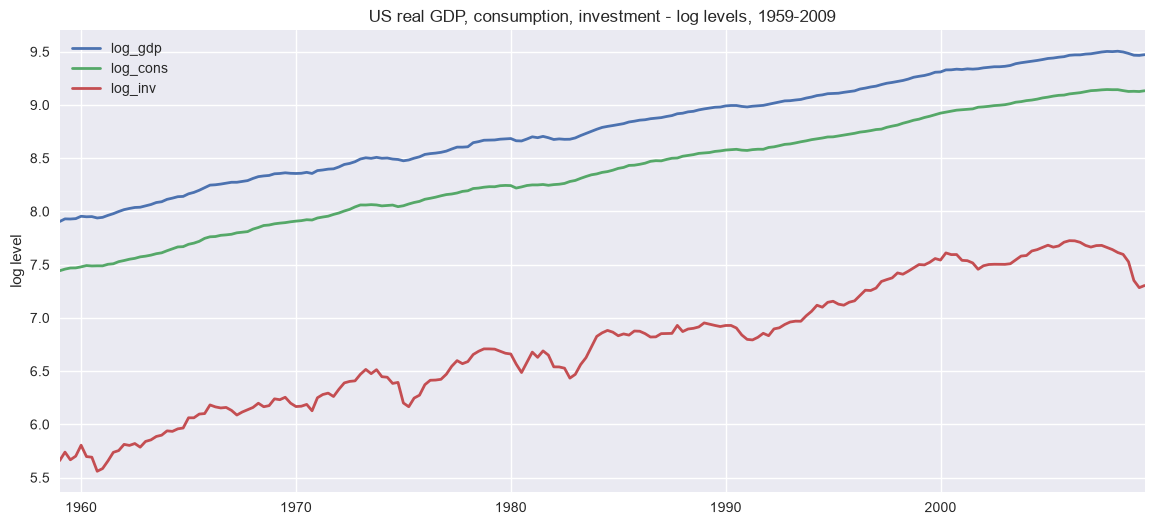

In [10]:
plot_multi(levels, "US real GDP, consumption, investment - log levels, 1959-2009",
           ylabel="log level")

A plot of the raw data always comes before any modeling. All three log series climb relentlessly across five decades — the visual signature of **non-stationary, trending series**. Two further things to register. First, the three lines climb *together*: they are bound by accounting (consumption and investment are components of GDP) and by the shared business cycle — this "moving together" is precisely what cointegration will later try to formalize. Second, look at `log_inv` (green): visibly jagged, with deep plunges in every recession (1975, 1982, 2008), while consumption is nearly smooth. Investment is the drama queen of the national accounts — remember that when we ask which variable does the *adjusting* in the error-correction model.

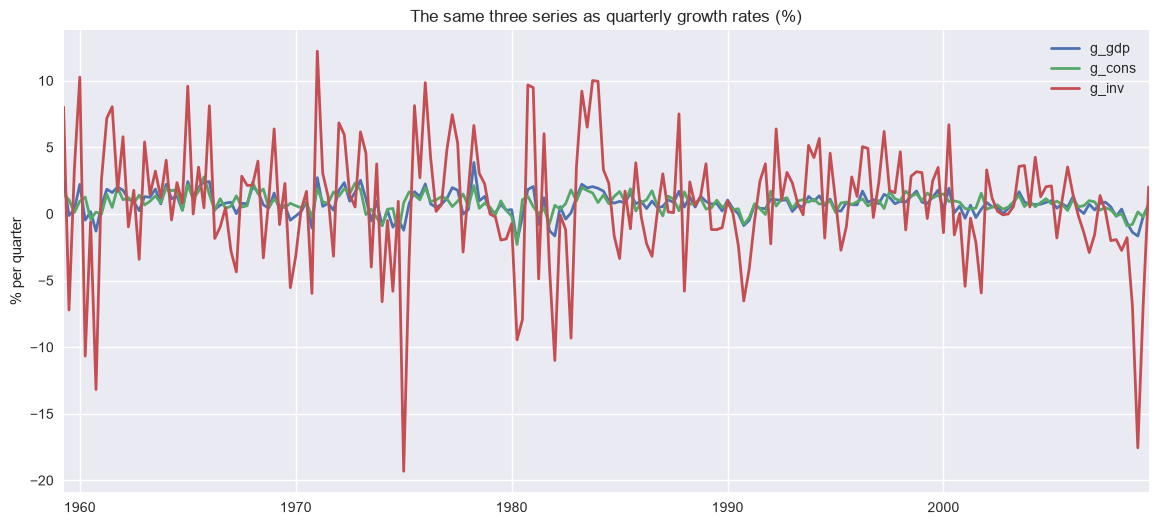

In [11]:
plot_multi(growth, "The same three series as quarterly growth rates (%)",
           ylabel="% per quarter")

The same data after the growth-rate transform: the trends are gone, all three series oscillate around a stable mean, and the scale difference is now stark — investment growth swings between roughly −10% and +10% per quarter while consumption growth rarely leaves the ±2% band. Visually these look stationary; the next cell asks the question formally, because eyeballs are not a test.

In [12]:
lv = run_stationarity(levels)
gr = run_stationarity(growth)
lv.join(gr.set_axis(lv.index), lsuffix=" (levels)", rsuffix=" (growth)")[
    ["ADF p (levels)", "KPSS p (levels)", "ADF p (growth)", "KPSS p (growth)"]]

,ADF p (levels),KPSS p (levels),ADF p (growth),KPSS p (growth)
series,,,,
log_gdp,0.383,0.01,0.0,0.1
log_cons,0.460,0.01,0.0,0.1
log_inv,0.569,0.01,0.0,0.1


The verdict table, reading levels against growth rates side by side (we align the two reports on one index purely for display). The pattern could not be cleaner:

- **Levels:** ADF p-values of 0.38–0.57 — nowhere near rejecting the unit root — while KPSS rejects stationarity at p = 0.01. Both tests agree: all three level series are **non-stationary**, integrated of order one, I(1). Each accumulates shocks and wanders.
- **Growth rates:** ADF p ≈ 0.000 (unit root firmly rejected) and KPSS p = 0.1 (no evidence against stationarity). Both tests agree again: differencing once produces **stationary, I(0)** series.

This confirms the I(1) diagnosis and sets up the fork in the road that structures everything below. Standard VAR and Granger machinery *requires* stationary inputs — estimated on I(1) levels, its standard errors and test distributions are simply wrong. So we can **difference** and work with growth rates: statistically safe, but differencing throws away all information about the *levels* — about long-run relationships. Or we can keep the levels and use the machinery purpose-built for them: **cointegration**. We will walk the first path (sections 1–2), then the second (sections 3–4), then meet the method that refuses to choose (section 5).

# 1. Vector Autoregression

The foundation of everything in this notebook. We build it in two rungs: one equation for one series (the scalar autoregression you have seen since episode 1), then the full multivariate system.

## A single equation: AR(1)

In [13]:
AR_LAGS = [1]                      # a pure AR(1): regress on lag 1 only

single_eq = AutoReg(growth["g_gdp"], lags=AR_LAGS, old_names=False).fit()
single_eq.params

const       0.533054
g_gdp.L1    0.301710
dtype: float64

We start with the simplest possible model of GDP growth: an **AR(1)**, writing this quarter's growth as a constant plus a coefficient times *last* quarter's growth plus noise. `AutoReg` with `lags=[1]` fits exactly that by OLS.

The two fitted numbers already tell a small story: the constant (~0.53) is tied to the average quarterly growth rate the process reverts to, and the lag-1 coefficient (~0.30) says growth has mild *momentum* — a strong quarter tends to be followed by an above-average quarter, but with a coefficient far below 1 the effect dies out geometrically within a year.

The limitation is structural, not statistical: this model believes GDP growth is explained *only by its own past*. Consumption and investment — two-thirds and a sixth of GDP respectively — are not consulted at all. The VAR fixes precisely this.

## The full system: VAR(p)

A **VAR(p)** replaces the scalars of an AR with vectors and matrices: each of the *k* variables is regressed on *p* lags of **all k variables** — its own past *and everyone else's*. For our three growth rates, that is three equations sharing one set of nine lagged regressors per lag. Because every equation has the identical regressor set, each can be estimated independently by OLS — no system estimator needed. This is Sims' original argument: instead of deciding by fiat which variables are exogenous, let *everything* depend on *everything's* past and let the data sort out the coefficients.

The one modeling decision is the lag order *p*, and it is a genuine bias/variance trade-off: **too few lags** leave dynamics unmodeled — the leftovers show up as serially correlated residuals and biased tests; **too many lags** burn parameters fast (each extra lag costs k² = 9 coefficients here), inflating standard errors and degrading forecasts. The standard referee is a set of information criteria, each balancing fit against a different complexity penalty.

In [14]:
order_sel = VAR(growth).select_order(maxlags=CFG.maxlags)
order_sel.summary()

,AIC,BIC,FPE,HQIC
0,-0.08408,-0.03355,0.9194,-0.06362
1,-0.3953*,-0.1932*,0.6735*,-0.3134*
2,-0.3843,-0.03052,0.6810,-0.2410
3,-0.3817,0.1237,0.6829,-0.1770
4,-0.3789,0.2780,0.6850,-0.1129
5,-0.3642,0.4444,0.6956,-0.03677
6,-0.3265,0.6336,0.7228,0.06230
7,-0.3031,0.8086,0.7407,0.1470
8,-0.2953,0.9680,0.7475,0.2162


`VAR(growth).select_order` fits every order from 0 to 8 on a common sample and reports four criteria; the asterisks mark each criterion's minimum. (Small gotcha for statsmodels users: there is a similarly named `select_order` in the *vecm* module which selects difference-lags for a VECM on level data — feeding it stationary growth rates answers a different question than the one you asked. The method on the `VAR` class, used here, is the right tool.)

How to read the three names, in one line each: **AIC** (Akaike) penalizes complexity mildly — it is inconsistent (can overestimate the true order asymptotically) but tends to minimize forecast error and, above all, *avoids underfitting*. **BIC** (Schwarz) penalizes hard — it is consistent (finds the true order as the sample grows) but notoriously prone to *underestimating* the lag length in small samples. **HQIC** (Hannan–Quinn) sits between them. The practical folklore: AIC for forecasting, BIC/HQIC when you care about the true structure — and when they disagree, check the residuals (we will do exactly that in the Toda–Yamamoto section, where the disagreement becomes consequential).

Here, for once, there is no drama: all four criteria agree on **p = 1**. Quarterly growth rates carry short memory.

In [15]:
VAR_LAG = 1                          # unanimous verdict of the criteria above

var_res = VAR(growth).fit(maxlags=VAR_LAG)
var_res.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 05, Jul, 2026
Time:                     08:19:25
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.107734
Nobs:                     201.000    HQIC:                 -0.225146
Log likelihood:          -812.973    FPE:                   0.737174
AIC:                    -0.304946    Det(Omega_mle):        0.694859
--------------------------------------------------------------------
Results for equation g_gdp
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.357952         0.091137            3.928           0.000
L1.g_gdp         -0.338056         0.172084           -1.964           0.049
L1.g_cons         0.746283         0.130411            5.723           0.000

We fit the VAR(1) and print the full summary — three equations, each with a constant and three lag coefficients. A guided read of the highlights:

- **`g_gdp` equation:** the strongest regressor is not GDP's own lag — that one is actually *negative* and marginal (−0.34, t ≈ −2.0). It is **lagged consumption growth** (coefficient ≈ 0.75, t ≈ 5.7). Yesterday's consumption tells you far more about today's GDP growth than yesterday's GDP does. Hold that thought for the Granger section.
- **`g_cons` equation:** consumption listens mostly to itself — its own lag (≈ 0.33, t ≈ 3.0) is the only solidly significant regressor. Smooth, self-propelled, hard for the others to predict; households do not revise spending plans much quarter to quarter.
- **`g_inv` equation:** the volatile one, and lagged consumption enters with a *huge* coefficient (≈ 4.6, t ≈ 6.7) — consumers pulling back is very bad news for next quarter's investment.
- The **residual correlation matrix** at the bottom shows large *contemporaneous* correlations (GDP–consumption ≈ 0.61, GDP–investment ≈ 0.76). The VAR's lags say nothing about causality *within* a quarter; that correlation is parked in the residuals, unexplained. Section 6 is entirely about this parked correlation.

In [16]:
train, valid = train_valid_split(growth, -CFG.horizon)

# --- single-equation baseline: a separate AR(1) per series ---
for col in growth.columns:
    pred = AutoReg(train[col], lags=AR_LAGS, old_names=False).fit().forecast(CFG.horizon)
    valid[col + "_single"] = pred.values

# --- joint VAR forecast: all three series at once ---
var_tr = VAR(train).fit(maxlags=VAR_LAG)
joint = var_tr.forecast(train.values[-VAR_LAG:], CFG.horizon)
for i, col in enumerate(growth.columns):
    valid[col + "_joint"] = joint[:, i]

valid.head(3)

,g_gdp,g_cons,g_inv,g_gdp_single,g_cons_single,g_inv_single,g_gdp_joint,g_cons_joint,g_inv_joint
2004Q4,0.863887,1.143534,2.040341,0.797194,0.873969,1.066565,0.842342,0.887170,1.208051
2005Q1,0.992864,0.745980,2.102162,0.813434,0.879166,1.049060,0.825941,0.885305,1.067337
2005Q2,0.425307,0.957666,-1.805400,0.817471,0.880405,1.047677,0.822586,0.881645,1.057283


Does joint modeling actually buy anything? We test it the only honest way: a chronological hold-out of the last `CFG.horizon = 20` quarters (2004Q4–2009Q3 — which, note, includes the financial crisis; forecasting into 2008 is nobody's idea of a fair fight, and that is precisely why it is a good test).

The baseline fits an independent AR(1) to each training series and forecasts 20 steps with `.forecast()`. The challenger refits the VAR(1) *on the training window only* (never reuse a model fitted on data that includes the validation period) and produces the joint forecast — note the API: `var_res.forecast()` needs the last `p` rows of training data as the launch state. Both sets of predictions land as new columns in `valid`, and `head(3)` confirms the alignment.

In [17]:
comparison = []
for col in growth.columns:
    s = forecast_metrics(valid[col], valid[col + "_single"])["RMSE"]
    j = forecast_metrics(valid[col], valid[col + "_joint"])["RMSE"]
    comparison.append({"series": col, "single RMSE": s, "joint RMSE": j,
                       "joint better?": j < s})
pd.DataFrame(comparison).set_index("series")

,single RMSE,joint RMSE,joint better?
series,,,
g_gdp,0.9272,0.9275,False
g_cons,0.7459,0.7451,True
g_inv,5.2876,5.2830,True


The verdict is honest rather than triumphant: the joint VAR edges out the single-equation baseline for consumption and investment and loses a hair on GDP — and every margin is thin. Two lessons, both worth more than a fake landslide. First, with a crisis in the validation window, *all* linear forecasts miss badly in absolute terms; the 2008 collapse is exactly the kind of break none of these models can see coming. Second, the modest gains are real but small because quarterly growth is dominated by fresh shocks — the R²s in the summary above were 5–15%. **The VAR's value in this notebook is not forecasting power; it is that the fitted system is the substrate every causal question below is asked on.** Cross-series prediction is the raw material; causality is the refined question.

# 2. Granger causality

A fitted VAR contains all the cross-lag coefficients; **Granger causality** is the formal question of whether a specific block of them is zero. The definition is operational, not philosophical: *X Granger-causes Y if the past of X contains information about the future of Y beyond what Y's own past already provides.* Concretely, compare two regressions — Y on its own lags (restricted) versus Y on its own lags plus X's lags (unrestricted) — and F-test whether X's lags jointly earn their keep.

## Bivariate Granger causality

The textbook version looks at two series in isolation. We ask the most classical question in empirical macro: between GDP and consumption, who leads whom?

In [18]:
GRANGER_MAXLAG = 4          # test at every lag from 1 to 4 quarters

print("does consumption growth lead GDP growth?")
print("   g_cons -> g_gdp :", granger_pvalue(growth, cause="g_cons", effect="g_gdp",
                                             maxlag=GRANGER_MAXLAG))
print("does GDP growth lead consumption growth?")
print("   g_gdp -> g_cons :", granger_pvalue(growth, cause="g_gdp", effect="g_cons",
                                             maxlag=GRANGER_MAXLAG))

does consumption growth lead GDP growth?
   g_cons -> g_gdp : {np.int64(1): 0.0, np.int64(2): 0.0, np.int64(3): 0.0, np.int64(4): 0.0}
does GDP growth lead consumption growth?
   g_gdp -> g_cons : {np.int64(1): 0.0912, np.int64(2): 0.7844, np.int64(3): 0.3692, np.int64(4): 0.2637}


A strikingly clean asymmetry, and a famous one:

- **Consumption → GDP: p ≈ 0.000 at every lag.** Consumption growth this quarter carries real information about GDP growth next quarter, and the verdict is unanimous from lag 1 through lag 4.
- **GDP → consumption: p = 0.09–0.78, never significant.** Knowing GDP grew fast this quarter tells you essentially nothing extra about consumption next quarter.

The economics reads well: households are *forward-looking* — consumption responds to expected lifetime income (the permanent-income hypothesis), so changes in consumer behavior front-run measured output rather than trail it. Consumption acts like an early sentiment reading on the economy.

But before celebrating, note what a bivariate test **cannot** rule out: some third variable — expectations, financial conditions, policy — driving both series with different delays would produce exactly this pattern with no direct link at all. The report calls this the omitted-variable trap, and it is the standing objection to every two-variable Granger result. Let's watch it bite.

In [19]:
print("does investment growth lead consumption growth?")
print("   g_inv -> g_cons :", granger_pvalue(growth, cause="g_inv", effect="g_cons",
                                             maxlag=GRANGER_MAXLAG))

does investment growth lead consumption growth?
   g_inv -> g_cons : {np.int64(1): 0.0153, np.int64(2): 0.3585, np.int64(3): 0.8533, np.int64(4): 0.8467}


Taken at face value, the lag-1 test says **yes**: investment Granger-causes consumption with p = 0.015. A story obligingly suggests itself (investment booms create jobs, jobs create spending...). But look at the whole profile: the significance exists *only* at lag 1 and evaporates completely at lags 2–4 (p = 0.36, 0.85, 0.85). A result this fragile to an arbitrary modeling choice should already make you suspicious — and there is an obvious confounder standing right outside this bivariate frame: the business cycle itself, i.e. GDP, moves both investment and consumption. The cure is to test *inside* the full system.

## Conditional (multivariate) Granger causality

Instead of pairwise regressions in isolation, we test each link *within the fitted three-variable VAR*: does X's past improve the prediction of Y **after controlling for the past of everything else in the system**? statsmodels exposes this directly on the fitted model as `test_causality`.

In [20]:
labels = growth.columns
gc_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
for eff in labels:
    for cau in labels:
        if eff == cau:
            gc_matrix.loc[eff, cau] = np.nan          # own-lags are not a causal claim
        else:
            gc_matrix.loc[eff, cau] = var_res.test_causality(eff, cau).pvalue

gc_matrix.round(3)          # rows = effect, columns = cause; small p => "cause -> effect"

,g_gdp,g_cons,g_inv
g_gdp,NaN,0.0,0.023
g_cons,0.360,NaN,0.049
g_inv,0.014,0.0,NaN


The double loop fills a 3×3 matrix of p-values — rows are the *effect*, columns the *cause*, diagonal blanked. Reading it:

- **cons → gdp: p ≈ 0.000.** The headline result survives conditioning. Consumption's lead on GDP is not an artifact of the omitted third variable.
- **inv → cons: p = 0.049.** The link that looked crisp in isolation (p = 0.015) has been *attenuated* to the very edge of significance once GDP's past is controlled for — a three-fold jump in the p-value. On simulated data with a known chain structure this kind of spurious link vanishes outright; on real data, where everything is a little bit connected to everything, the typical outcome is exactly this: the link weakens to the boundary and your confidence in it should weaken accordingly.
- **cons → inv: p ≈ 0.000** and **gdp → inv: p = 0.014** — investment is the *downstream* variable of this system, listening to everyone. Consistent with investment being the accelerator: firms commit capital in response to demonstrated demand.

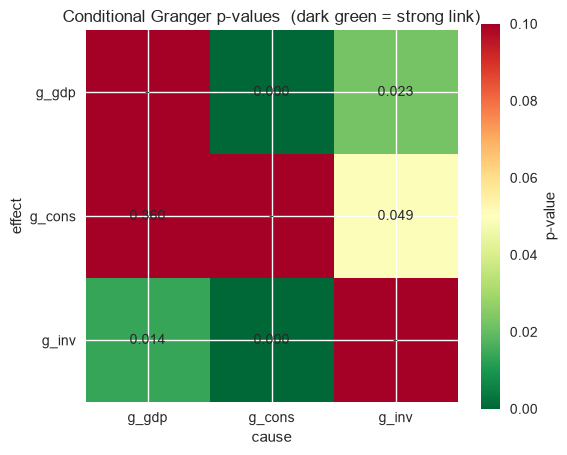

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(gc_matrix.fillna(1.0).astype(float).values,
               cmap="RdYlGn_r", vmin=0, vmax=0.1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("cause"); ax.set_ylabel("effect")
ax.set_title("Conditional Granger p-values  (dark green = strong link)")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = gc_matrix.iloc[i, j]
        ax.text(j, i, "-" if np.isnan(v) else f"{v:.3f}",
                ha="center", va="center", zorder=3)
fig.colorbar(im, ax=ax, label="p-value")
plt.show()

The same matrix as a heatmap — the closest thing Granger analysis produces to a causal graph. Dark green cells are strong links; the arrows they imply: `cons → gdp`, `cons → inv` clearly, with `gdp → inv` and `inv → cons` in the pale borderline zone. Consumption sits at the top of this little food chain, which is a satisfying picture — until you remember we just ran **six hypothesis tests** and are cheerfully reading the two that came out around p ≈ 0.05 as discoveries.

In [22]:
N_TESTS = int(gc_matrix.notna().sum().sum())        # 6 off-diagonal tests
bonferroni = CFG.signif / N_TESTS

survivors = (gc_matrix < bonferroni)
print(f"tests run: {N_TESTS}   Bonferroni-adjusted threshold: {bonferroni:.4f}\n")
print("links surviving the correction:")
for eff in labels:
    for cau in labels:
        if survivors.loc[eff, cau] == True:
            print(f"   {cau} -> {eff}   (p = {gc_matrix.loc[eff, cau]:.4f})")

tests run: 6   Bonferroni-adjusted threshold: 0.0083

links surviving the correction:
   g_cons -> g_gdp   (p = 0.0000)
   g_cons -> g_inv   (p = 0.0000)


Testing every ordered pair is a **multiple-testing problem**: at a 5% threshold, six tests carry roughly a one-in-four chance of at least one false discovery even if no links exist. The **Bonferroni correction** — divide the significance level by the number of tests, here 0.05/6 ≈ 0.0083 — is the bluntest fix, controlling the family-wise error rate at the price of some power.

The pruning is instructive: only **cons → gdp** and **cons → inv** survive. The two borderline links (`inv → cons` at 0.049, `gdp → inv` at 0.014) are exactly the ones that fall — the correction removed precisely the edges we had already flagged as fragile. That convergence of evidence (fragile across lags, attenuated by conditioning, killed by correction) versus the robustness of the consumption links is what a defensible Granger analysis looks like. In genuinely high-dimensional settings — dozens of series, hundreds of ordered pairs — Bonferroni becomes too blunt and the modern toolkit switches to sparse VARs with false-discovery-rate control; the principle, though, is the one you just watched: **never read a matrix of p-values as if each cell were the only test you ran.** *(Standing asterisk: all of this is predictive precedence. Consumption forecasting GDP does not mean stimulating consumption raises GDP.)*

# 3. Cointegration: long-run equilibrium among trending series

Sections 1–2 took the differencing fork: safe, stationary, and *blind to levels*. A growth-rate VAR can tell you consumption growth leads GDP growth; it cannot say anything about the ratio of consumption to GDP, because that information was destroyed by `diff()`. To ask long-run questions we must go back to the I(1) levels — and the levels are a minefield. Let's step on a mine deliberately first.

## The spurious regression trap

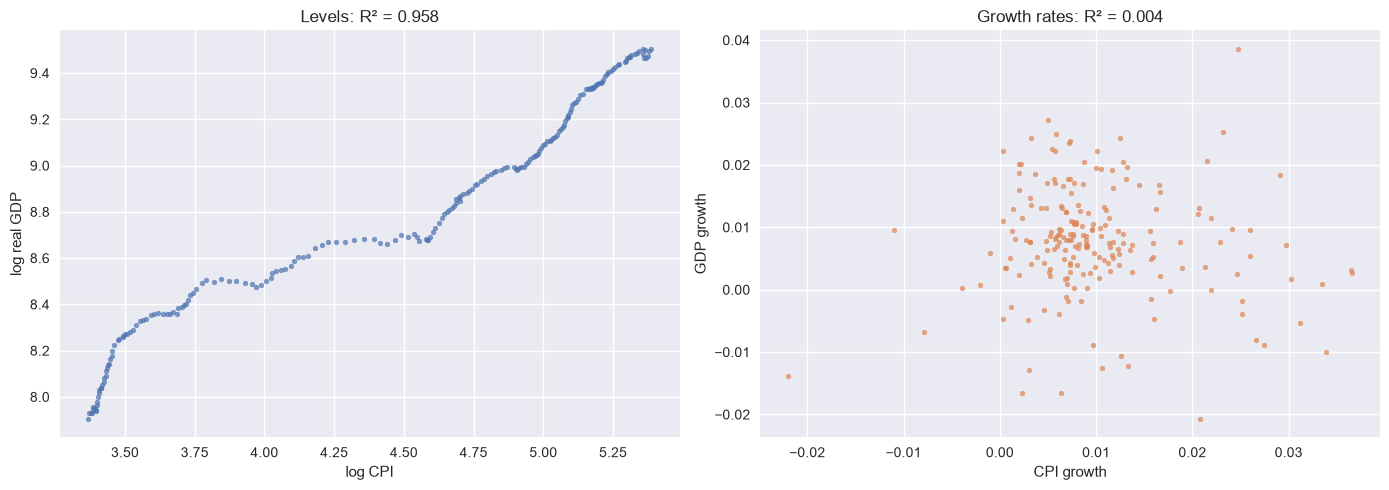

R² in levels: 0.958    R² in growth rates: 0.004


In [23]:
log_cpi = np.log(md_raw["cpi"])

# levels regression: log real GDP on log CPI
X_lvl = sm.add_constant(log_cpi.values)
r2_lvl = sm.OLS(levels["log_gdp"].values, X_lvl).fit().rsquared

# the same regression on growth rates
g_gdp_, g_cpi_ = levels["log_gdp"].diff().dropna(), log_cpi.diff().dropna()
r2_gr = sm.OLS(g_gdp_.values, sm.add_constant(g_cpi_.values)).fit().rsquared

fig, axes = plt.subplots(1, 2, figsize=(CFG.img_dim1, 5))
axes[0].scatter(log_cpi, levels["log_gdp"], s=12, alpha=0.7)
axes[0].set(title=f"Levels: R² = {r2_lvl:.3f}", xlabel="log CPI", ylabel="log real GDP")
axes[1].scatter(g_cpi_, g_gdp_, s=12, alpha=0.7, color="#DD8452")
axes[1].set(title=f"Growth rates: R² = {r2_gr:.3f}", xlabel="CPI growth", ylabel="GDP growth")
plt.tight_layout(); plt.show()

print(f"R² in levels: {r2_lvl:.3f}    R² in growth rates: {r2_gr:.3f}")

We regress log *real* GDP on the log *price level* — real output "explained" by how expensive things are, a relationship with no serious economic content at this frequency. The levels regression returns **R² = 0.958**. Not a typo: two variables whose main shared property is *drifting upward for fifty years* produce a near-perfect fit, complete (if you check) with enormous t-statistics. Rerun the identical regression on growth rates and the R² collapses to **0.004** — nothing there.

This is the **spurious regression** phenomenon: when both series are I(1), the usual OLS distribution theory fails and R²/t-statistics become meaningless — any two stochastic trends look related. It is the single best argument for the stationarity discipline of sections 1–2. But notice the trap it leaves us in: if level regressions are radioactive and differencing destroys level information, how do we ever test a *genuine* long-run level relationship — like "consumption is a stable share of GDP"?

**Cointegration** is the escape hatch. Two or more I(1) series are cointegrated if some linear combination of them is stationary — individually they wander, but they wander *together*, tethered by an equilibrium the combination measures the deviation from. When that holds, a levels relationship is meaningful after all, and there is even a theorem (Granger's representation theorem) guaranteeing an error-correction structure. The question is how to *test* for it.

## Engle–Granger: the two-step test

In [24]:
log_m1 = np.log(md_raw["m1"])          # money stock: our control pair partner

print("consumption vs GDP  (theory says: cointegrated - stable consumption share)")
print("   Engle-Granger p-value:", round(coint(levels["log_cons"], levels["log_gdp"])[1], 4))

print("investment vs money stock  (no theory ties these levels together)")
print("   Engle-Granger p-value:", round(coint(levels["log_inv"], log_m1)[1], 4))

consumption vs GDP  (theory says: cointegrated - stable consumption share)
   Engle-Granger p-value: 0.0294
investment vs money stock  (no theory ties these levels together)
   Engle-Granger p-value: 0.2145


The **Engle–Granger** procedure is cointegration testing at its most transparent: step one, regress one level series on the other by OLS and keep the residuals; step two, ADF-test the residuals for a unit root. If the residuals are stationary, the regression line is a genuine long-run anchor — the series never drift far from it. One crucial technicality is baked into `coint()`: because OLS *chose* the combination to make residuals as small as possible, ordinary ADF critical values are too easy to beat; the test uses the corrected **Phillips–Ouliaris** distributions instead.

The results split exactly as theory predicts: consumption–GDP rejects no-cointegration at p = 0.029 (a stable long-run consumption share — one of the classic "great ratios" of macroeconomics), while investment–money doesn't come close (p = 0.21) — both are I(1), both trend, but nothing ties their levels together, and unlike the spurious OLS of the previous cell, this test correctly says so.

Engle–Granger's virtues are simplicity and interpretability; its limits are structural: it handles only **one** cointegrating relation, it is **asymmetric** (the choice of left-hand variable changes the residuals, and can change the verdict), and errors from the first-stage OLS contaminate the second stage. For a *system* of three variables that can share up to two independent equilibria, we need the industrial-strength tool.

## Johansen: system-wide cointegration

In [25]:
DET_ORDER = 0          # constant inside the cointegrating relation, no trend
K_AR_DIFF = 2          # short-run lags (in differences) for the underlying VECM

joh = coint_johansen(levels, det_order=DET_ORDER, k_ar_diff=K_AR_DIFF)

trace_table = pd.DataFrame({
    "null hypothesis": [f"rank <= {i}" for i in range(levels.shape[1])],
    "trace statistic": np.round(joh.lr1, 2),
    "5% critical value": np.round(joh.cvt[:, 1], 2),
    "reject?": joh.lr1 > joh.cvt[:, 1],
})
selected = select_coint_rank(levels, det_order=DET_ORDER, k_ar_diff=K_AR_DIFF,
                             method="trace", signif=CFG.signif)
print("selected cointegration rank:", selected.rank)
trace_table

selected cointegration rank: 1


,null hypothesis,trace statistic,5% critical value,reject?
0,rank <= 0,30.64,29.80,True
1,rank <= 1,10.55,15.49,False
2,rank <= 2,2.96,3.84,False


The **Johansen test** treats all three variables symmetrically inside one maximum-likelihood framework and asks for the **cointegration rank** *r*: how many independent stationary combinations exist? Rank 0 means no cointegration (a difference-VAR is correct); full rank 3 would mean the levels were stationary all along; anything in between means *r* genuine long-run relations. The **trace test** proceeds sequentially: test "rank ≤ 0", and if rejected, "rank ≤ 1", and so on; the first non-rejection pins down *r*.

Our table: "rank ≤ 0" is rejected — trace statistic 30.64 against a 5% critical value of 29.80 — while "rank ≤ 1" is comfortably not rejected (10.55 vs 15.49). Verdict: **rank 1**, a single long-run equilibrium binding GDP, consumption, and investment.

But look at *how* the first rejection happened: 30.64 versus 29.80, a margin of less than 3%. This is evidence at the knife's edge, and knife-edge results deserve a robustness check. The Johansen test is notoriously sensitive to two specification choices we made silently: the deterministic-term assumption (`det_order`) and the short-run lag count (`k_ar_diff`). The disciplined approach (the report's Pantula principle formalizes it) is to examine the verdict across specifications — so let's do exactly that.

In [26]:
grid = pd.DataFrame(index=[f"det_order={d}" for d in (0, 1)],
                    columns=[f"k_ar_diff={k}" for k in (1, 2, 3, 4)], dtype=int)
for d in (0, 1):
    for k in (1, 2, 3, 4):
        grid.loc[f"det_order={d}", f"k_ar_diff={k}"] = select_coint_rank(
            levels, det_order=d, k_ar_diff=k, method="trace", signif=CFG.signif).rank
grid.astype(int)          # selected rank under each specification

,k_ar_diff=1,k_ar_diff=2,k_ar_diff=3,k_ar_diff=4
det_order=0,0,1,1,1
det_order=1,0,0,0,1


Eight specifications, one question. The grid splits down the middle: with a constant-only deterministic term (`det_order=0`) the test finds rank 1 at every lag count except the shortest; allow a linear trend in the data (`det_order=1`) and the rank drops to 0 almost everywhere. **The existence of a long-run equilibrium among these three series depends on an auxiliary assumption about trends.**

This is not a failed demo — it *is* the lesson, and it is exactly what the practitioner literature warns about. Fifty years of US data include the productivity slowdown, the Great Moderation, and a financial crisis; the "great ratios" have genuinely drifted (consumption's share of GDP rose from ~63% to ~71% across our sample — plot `log_cons − log_gdp` and you will see a slow climb, not mean-reversion). Real macro cointegration is *borderline*, and an honest analyst reports it as such rather than quietly picking the specification that flatters the hypothesis. We will proceed with the rank-1, `det_order=0` reading — it is defensible and lets us demonstrate the VECM — but the fragility just documented is a fact we carry forward, and it will *motivate* section 5.

# 4. Vector Error Correction: dynamics tethered to equilibrium

Conditional on cointegration, the right model is the **VECM** — a VAR rewritten in differences, plus one crucial extra term per equation: the lagged *deviation from equilibrium*. Each variable's growth this quarter responds to short-run dynamics **and** to how far the system strayed from its long-run relation last quarter. The equilibrium is encoded in the cointegrating vector **β** (the recipe for the stationary combination), and each variable's responsiveness to disequilibrium is its **α** loading — the *speed of adjustment*, the share of the gap closed per quarter.

In [27]:
COINT_RANK = 1        # the (borderline) verdict of the Johansen test above

vecm_res = VECM(levels, k_ar_diff=K_AR_DIFF, coint_rank=COINT_RANK,
                deterministic="ci").fit()

beta = pd.Series(vecm_res.beta.ravel(), index=levels.columns, name="beta (equilibrium recipe)")
alpha = pd.Series(vecm_res.alpha.ravel(), index=levels.columns, name="alpha (adjustment speed)")
pd.concat([beta.round(3), alpha.round(4)], axis=1)

,beta (equilibrium recipe),alpha (adjustment speed)
log_gdp,1.000,0.0003
log_cons,-6.448,0.0025
log_inv,4.328,-0.0145


`deterministic="ci"` places the constant *inside* the cointegrating relation (matching `det_order=0` above), and `coint_rank=1` imposes the single equilibrium. Two parameter blocks come back:

**β = [1, −6.45, 4.33]** — the estimated equilibrium recipe, normalized on `log_gdp`. Here is the honesty checkpoint: a textbook great-ratio equilibrium would look something like `log_gdp − a·log_cons − b·log_inv` with weights near the component shares. Coefficients of −6.4 and +4.3 do not look like that; they are what maximum likelihood extracts when the underlying equilibrium is weak and drifting, as our sensitivity grid warned. Borderline rank evidence buys imprecisely identified equilibrium coefficients.

**α = [0.0003, 0.0025, −0.0145]** — who does the correcting when the system is out of equilibrium? GDP essentially ignores the gap (α ≈ 0.000), consumption barely reacts (0.003), and **investment carries the adjustment** (−0.015, an order of magnitude larger). That, at least, is exactly the economics we anticipated from the very first plot: the volatile component absorbs the shocks; the smooth components set the anchor. Even with a shaky β, the *division of labor* in α is textbook.

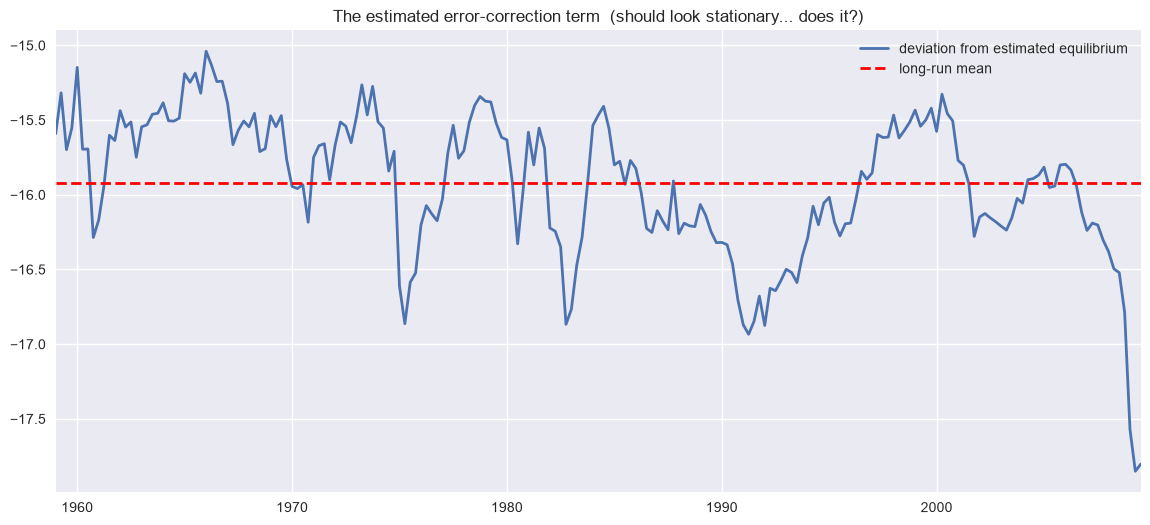

ADF p-value of the spread: 0.2562


In [28]:
spread = levels @ vecm_res.beta.ravel()

ax = pd.Series(spread, name="deviation from estimated equilibrium").plot(linewidth=2, xlabel="")
ax.axhline(spread.mean(), color="red", linestyle="--", linewidth=2, label="long-run mean")
ax.set_title("The estimated error-correction term  (should look stationary... does it?)")
plt.legend(); plt.show()

print("ADF p-value of the spread:", round(adfuller(spread.dropna())[1], 4))

The final exam for any claimed cointegrating relation: compute the combination `levels @ β` and *look at it*. A healthy error-correction term oscillates busily around its mean and returns to it quickly — a coiled spring. Ours wanders in slow, multi-year swells — sitting above the mean for most of the 1960s, sagging through long stretches of the late 1980s and early 1990s — and then exits the sample with a violent plunge in 2008–09 that looks like anything but mean-reversion. The formal check agrees with the eyeball: **ADF p = 0.256** — we cannot reject a unit root in the very combination the model treats as stationary.

Verdict, stated plainly: over this half-century sample, the GDP–consumption–investment "equilibrium" is statistically fragile — borderline rank evidence, specification-dependent, with a sluggish spread. A pairs trader would walk away; those decade-long swells are exactly the mean-reversion trades that ruin you. A macro-econometrician notes that the great-ratio drift is a known feature of this era and moves to methods that don't *require* resolving the question. That is precisely where we go next — and this uncertainty is the best possible motivation for it: **section 5's entire reason to exist is that "is it cointegrated?" is often unanswerable, and your causality test shouldn't have to wait for the answer.**

# 5. Toda–Yamamoto: causality without the pre-test minefield

Recap of our predicament. Granger tests need stationary data. Our levels are I(1). Differencing fixes stationarity but discards long-run information — and if the series *are* cointegrated, a difference-VAR is misspecified (it omits the error-correction term). But whether they are cointegrated is, as we just spent two sections discovering, genuinely uncertain. Every route requires winning a pre-test we might lose: unit-root tests have low power, cointegration verdicts flip with specification, and mistakes at either stage silently invalidate the causality test built on top. Running standard Granger tests directly on I(1) levels is no escape — the Wald statistic loses its chi-squared distribution (the offending non-stationary level term distorts the critical values) and produces spurious causality at well-documented rates.

**Toda and Yamamoto (1995)** offer a way out that is almost insultingly simple: fit the VAR *in levels anyway*, but with `d_max` extra lags, where `d_max` is the highest integration order suspected in the system — then Wald-test only the original `p` lags and *ignore the extra ones entirely*. The unrestricted augmenting lags soak up the non-stationarity, and the tested block behaves asymptotically as if everything were stationary: standard chi-squared inference, valid whether the series are I(0), I(1), or cointegrated in any combination. No unit-root pre-test to lose, no cointegration verdict to depend on. The price: a slightly over-parameterized model — mild efficiency loss, bought cheaply.

We deploy it on the most fought-over causal question in postwar macroeconomics: **does money cause income?** Monetarists (Friedman) read money-supply movements as driving output; the Keynesian rebuttal argued money passively accommodates economic activity. Sims' 1972 paper on exactly this question is where Granger causality entered macroeconomics. Our arena: log M1 versus log real GDP.

In [29]:
money = pd.concat([log_m1, levels["log_gdp"]], axis=1)
money.columns = ["log_m1", "log_gdp"]

# integration order of the two series: test levels and first differences
run_stationarity(money).join(
    run_stationarity(money.diff().dropna()).set_axis(money.columns),
    lsuffix=" (levels)", rsuffix=" (diffs)")[
    ["ADF p (levels)", "ADF p (diffs)", "ADF -> stationary? (diffs)"]]

,ADF p (levels),ADF p (diffs),ADF -> stationary? (diffs)
series,,,
log_m1,0.824,0.002,True
log_gdp,0.383,0.000,True


Step one of the recipe: establish `d_max`, the *maximum* order of integration in the system. Both level series flunk the ADF test (p = 0.82 for money, 0.38 for GDP — deep in unit-root territory), while both first differences pass decisively (p ≤ 0.002). Both series are I(1) and neither needs a second difference, so **`d_max = 1`**. Note the asymmetry of roles here: we still *run* unit-root tests, but they now only set the number of augmenting lags — a much lighter burden than before, where a wrong verdict poisoned everything downstream. Getting `d_max` generously wrong (say, using 2) merely wastes a lag; the test remains valid.

In [30]:
money_order = VAR(money).select_order(maxlags=CFG.maxlags)
print("levels-VAR lag order by criterion:", dict(money_order.selected_orders))

for p_try in [2, 3, 6]:
    white = VAR(money).fit(p_try, trend="c").test_whiteness(nlags=12, adjusted=True)
    print(f"p = {p_try}: residual whiteness p = {white.pvalue:.4f}   "
          f"(H0: no serial correlation left)")

levels-VAR lag order by criterion: {'aic': np.int64(6), 'bic': np.int64(2), 'hqic': np.int64(3), 'fpe': np.int64(6)}
p = 2: residual whiteness p = 0.0004   (H0: no serial correlation left)
p = 3: residual whiteness p = 0.0394   (H0: no serial correlation left)
p = 6: residual whiteness p = 0.5498   (H0: no serial correlation left)


Step two: choose the base lag order `p` for the levels VAR — and this time the criteria *disagree*: BIC says 2, HQIC says 3, AIC says 6. Earlier we noted the folklore (BIC parsimonious, AIC generous) and promised the tiebreaker: **the residuals decide**. A Granger-type test is built on the assumption that the VAR has absorbed all the serial dependence; leftover autocorrelation biases the test itself. The whiteness check (a Portmanteau test — null: residuals are white noise) is unambiguous: BIC's p = 2 leaves glaring serial correlation (p = 0.0004), HQIC's p = 3 still fails at 5% (p = 0.039), and only AIC's **p = 6** produces clean residuals (p = 0.55). This is the report's warning about BIC underfitting in small samples, caught in the act on real data. We take p = 6, so the fitted system is a VAR(6 + 1) = VAR(7) in levels, with the 7th lag as the untested buffer.

In [31]:
# the naive (INVALID) benchmark: standard Granger tests straight on the I(1) levels
print("naive Granger on raw levels - do not trust these numbers:")
print("   m1 -> gdp :", granger_pvalue(money, cause="log_m1", effect="log_gdp", maxlag=4))
print("   gdp -> m1 :", granger_pvalue(money, cause="log_gdp", effect="log_m1", maxlag=4))

naive Granger on raw levels - do not trust these numbers:
   m1 -> gdp : {np.int64(1): 0.0911, np.int64(2): 0.2922, np.int64(3): 0.079, np.int64(4): 0.1153}
   gdp -> m1 : {np.int64(1): 0.6729, np.int64(2): 0.1524, np.int64(3): 0.2085, np.int64(4): 0.1451}


Before the valid test, the invalid one — run deliberately, as the benchmark to beat. Standard Granger tests straight on the I(1) levels flirt with `m1 → gdp` (p-values of 0.08–0.09 at lags 1 and 3: "significant at the 10% level!", a monetarist might be tempted to report) and shrug at `gdp → m1` (p = 0.15–0.67). Remember both verdicts; the distribution theory behind these p-values is broken, and we are about to see how much that matters.

In [32]:
TY_P = 6          # base lag order (AIC + clean residuals)
TY_DMAX = 1       # both series are I(1)

ty_results = []
for p_robust in [4, 5, 6]:                       # verdicts should not hinge on one p
    for cau, eff in [("log_m1", "log_gdp"), ("log_gdp", "log_m1")]:
        r = toda_yamamoto(money, cause=cau, effect=eff, p=p_robust, d_max=TY_DMAX)
        ty_results.append({"lags": p_robust, "cause": cau, "effect": eff, **r})
pd.DataFrame(ty_results).set_index(["lags", "cause"])

effect     wald  df       p  causes?
lags cause                                         
4    log_m1   log_gdp    3.626   4  0.4590    False
     log_gdp   log_m1   32.387   4  0.0000     True
5    log_m1   log_gdp    3.319   5  0.6510    False
     log_gdp   log_m1  119.562   5  0.0000     True
6    log_m1   log_gdp    9.253   6  0.1598    False
     log_gdp   log_m1  192.803   6  0.0000     True

The Toda–Yamamoto verdict, run at the chosen p = 6 and — because we have learned to distrust single-specification results — at p = 4 and 5 as well:

- **money → income: NO.** p = 0.16–0.65 across all three lag choices. The naive levels test's flirtation with significance was exactly the spurious causality the broken distribution theory produces; done properly, it evaporates.
- **income → money: YES, overwhelmingly.** Wald statistics of 33–193, p ≈ 0.0000, at every lag choice. The naive test *missed* this direction entirely (p = 0.15 at best) — non-stationarity doesn't just create false positives, it hides true positives.

Both verdicts **flipped** relative to the invalid benchmark. And the surviving direction tells a coherent story: money-stock movements do not front-run output; instead, economic activity drives money holdings — income rises, households and firms demand more transaction balances, and the banking system supplies them. Money is the passenger, not the driver, in this sample. (This is one dataset, M1, and a bivariate system — the literature has fought over every one of those choices — but the *methodological* point stands regardless: the valid and invalid tests disagree completely, and only one of them has a defensible distribution theory.)

*One caveat the report insists on, and honesty demands here: TY has a known blind spot. When causality flows primarily through the cointegrating relation itself — the long-run level channel — the augmenting lag absorbs it, and TY can lose severe amounts of power (simulations show rejection rates dropping from 80% to 10% in strongly cointegrated systems). Given that our own cointegration evidence for the money system is as murky as everything else in this notebook, the m1 → gdp "no" is best read as "no short-run predictive channel"; a long-run channel would be harder for this test to see.*

# 6. Structural VAR: the missing quarter

Everything so far shares one silent restriction: causes take *at least one quarter* to act. Every Granger-type statement is about lagged influence, and effects inside the sampling interval are invisible to it — worse, they are not absent from the data, they are parked in the **residual correlations** we noticed back in the VAR summary (GDP–investment residuals correlated at ~0.8). Within a quarter, things clearly move together; the reduced-form VAR just refuses to say who moves whom.

The **Structural VAR** confronts this by positing contemporaneous structure: a matrix of same-quarter causal links whose estimation requires extra assumptions, because the data alone cannot separate "A moves B within the quarter" from "B moves A within the quarter" — both produce the same covariance. The classic identifying assumption is the **recursive (Cholesky) ordering**: arrange the variables from "slowest" to "fastest", and allow same-quarter influence to flow only downward. The ordering *is* the causal assumption — untestable from this data, imposed by the analyst, and consequential. This is the field's honest trade: contemporaneous causal claims are purchasable only with theory.

We demonstrate on the canonical monetary-policy system: **output growth, inflation, and the T-bill rate**, ordered exactly so. The logic of the ordering: production decisions are sticky within a quarter (output reacts to nothing contemporaneously); prices respond to current activity but not to current policy; the policy rate — set by a committee that watches everything in real time — responds to both within the quarter. Reasonable, standard... and an assumption.

In [33]:
monetary = pd.concat([growth["g_gdp"], md_raw["infl"], md_raw["tbilrate"]], axis=1).dropna()
monetary.columns = ["g_gdp", "infl", "tbilrate"]      # column order = causal ordering!

run_stationarity(monetary)

,ADF p,ADF -> stationary?,KPSS p,KPSS -> stationary?
series,,,,
g_gdp,0.000,True,0.100,True
infl,0.027,True,0.081,True
tbilrate,0.280,False,0.054,True


The stationarity check delivers one clean verdict and one honest wrinkle. Output growth and inflation pass (ADF p = 0.000 and 0.027). The T-bill rate is the wrinkle: ADF p = 0.28 fails to reject a unit root, while KPSS (p = 0.056) *just barely* declines to reject stationarity — the tests disagree, which per our earlier rule means "boundary case, hold conclusions loosely". A nominal interest rate cannot literally be a random walk (it is bounded below and policy-controlled), but over 1959–2009 — Volcker's 15% peaks to near-zero — it is certainly *persistent*. The monetary-VAR literature since Sims has typically kept the rate in levels precisely because differencing it would discard the policy signal; we follow that convention, flagging it as the standard-practice compromise it is. One more assumption on the pile — SVAR work is an exercise in stacking defensible assumptions and knowing you did.

lag order chosen by AIC: 6


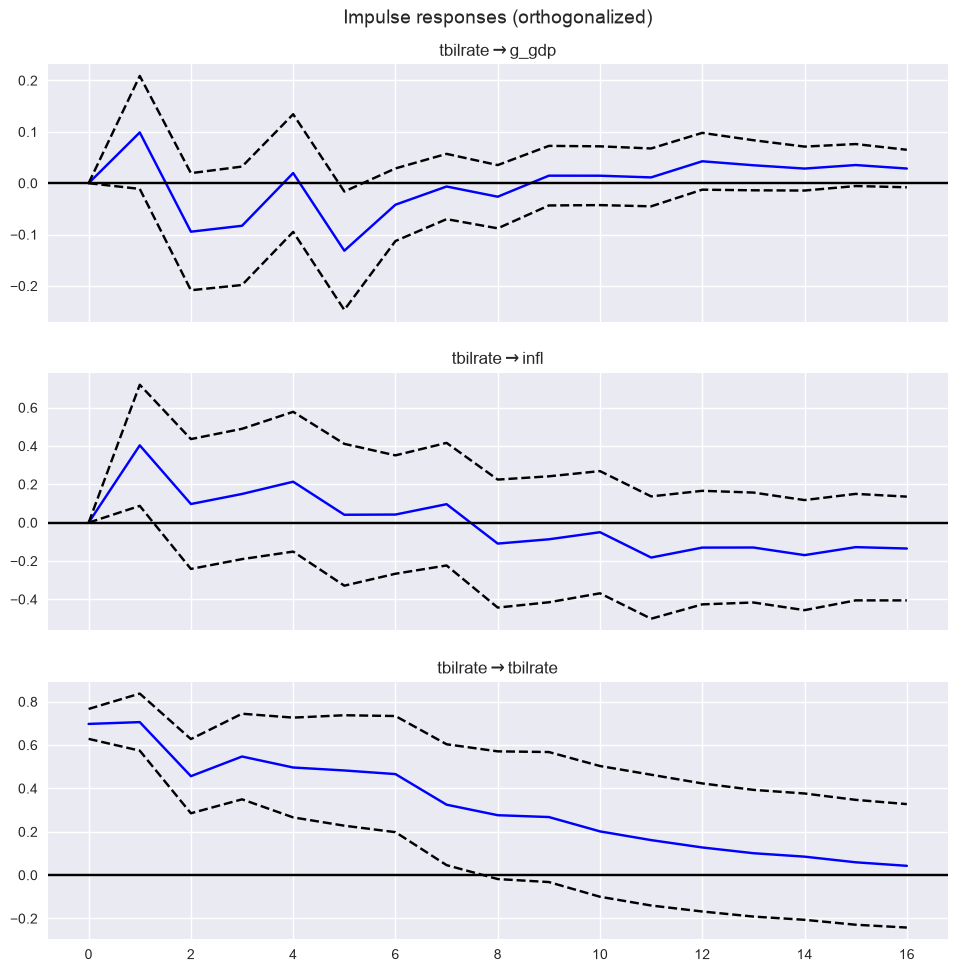

In [34]:
svar_res = VAR(monetary).fit(maxlags=CFG.maxlags, ic="aic")
print("lag order chosen by AIC:", svar_res.k_ar)

IRF_STEPS = 16
irf = svar_res.irf(IRF_STEPS)
irf.plot(orth=True, impulse="tbilrate")
plt.show()

We fit the VAR (AIC selects 6 lags) and compute **orthogonalized impulse response functions** — `orth=True` applies the Cholesky factorization in our column order, converting the correlated reduced-form residuals into uncorrelated "structural" shocks. The plot shows the economy's response, quarter by quarter for four years, to a one-standard-deviation surprise in the T-bill rate — the closest a 1959–2009 observational dataset gets to answering "what happens when the Fed unexpectedly tightens?"

Reading the three panels (dashed lines are 95% confidence bands):

- **Output growth** dips negative from about two quarters out and stays mostly below zero for a couple of years — the contractionary effect of tighter money, arriving with the famous "long and variable" lag. The bands are wide; macro effects are estimated, not etched.
- **Inflation** *rises* for the first several quarters after the tightening. This is not a bug in our code — it is the celebrated **price puzzle**, one of the most replicated artifacts in empirical macro. The standard diagnosis: the Fed tightens when it *sees inflation coming* that our little three-variable system does not; the model then misreads the anticipatory tightening as causing the inflation that follows. It is the omitted-variable trap from section 2, resurfacing at the structural level — richer systems add commodity prices or Fed forecasts to make it fade.
- **The rate itself** decays slowly back — policy surprises persist.

The price puzzle is the perfect closing exhibit for identification-by-assumption: the recursive ordering was plausible, the code is correct, and the result still contains a well-understood distortion because the *system is too small for the assumption to be true*. Structural conclusions inherit the quality of their identifying assumptions — always.

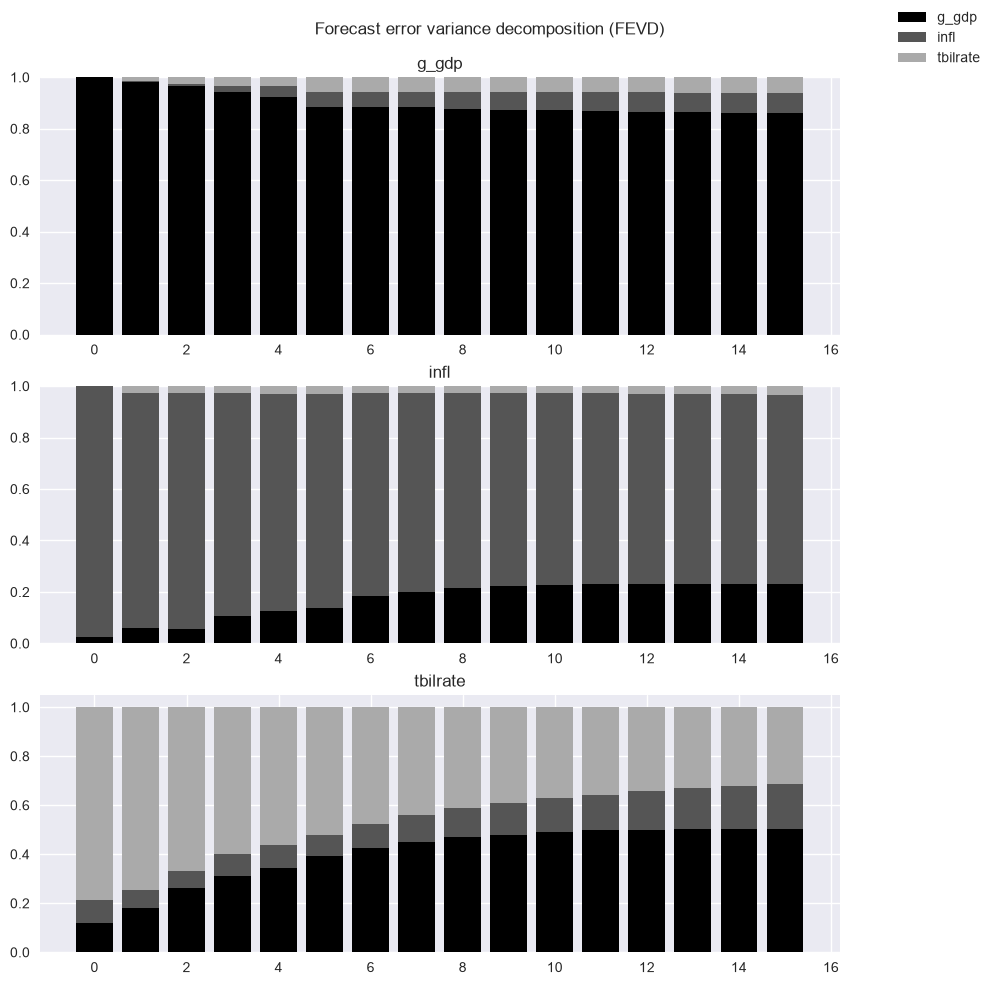

In [35]:
fevd = svar_res.fevd(IRF_STEPS)
fevd.plot()
plt.show()

The **forecast error variance decomposition** asks the complementary question: at each horizon, what *share* of each variable's forecast uncertainty is attributable to each structural shock? Where the IRF traces one shock's ripple, the FEVD apportions blame.

The headline readings at the four-year horizon: output-growth uncertainty remains ~86% own-shock — neither inflation nor policy surprises explain much of GDP's wiggle, consistent with the modest (if real) IRF response. The interesting panel is the **T-bill rate**: only about half its variance is its own shock; roughly 50% is explained by output shocks with another chunk from inflation. The "policy instrument" is substantially *endogenous* — the Fed spends most of its time reacting to the economy rather than surprising it. Which is, when you think about it, exactly what a central bank is supposed to look like in the data — and a fitting last empirical word for a notebook about disentangling who-drives-whom: the variable everyone calls "the cause" is itself mostly an effect.

# 7. Synthesis: choosing a method

One dataset, six methods, and a decision rule that falls straight out of the ladder. The choice is driven first by **stationarity structure**, then by the **kind of causal question** you are asking.

In [36]:
synthesis = pd.DataFrame([
    {"method": "Reduced-form VAR",  "data needs": "stationary I(0)",
     "question answered": "joint lagged prediction",
     "handles cointegration": "no (pre-difference)",
     "main limitation": "silent on contemporaneous links; linear only"},
    {"method": "Granger causality", "data needs": "stationary I(0)",
     "question answered": "does X's past add information about Y?",
     "handles cointegration": "no (pre-difference)",
     "main limitation": "omitted variables; multiple testing; predictive not manipulative"},
    {"method": "Engle-Granger",     "data needs": "I(1) pair",
     "question answered": "do two series share a long-run anchor?",
     "handles cointegration": "one relation only",
     "main limitation": "pairwise; order-sensitive; two-stage error propagation"},
    {"method": "Johansen + VECM",   "data needs": "I(1) system",
     "question answered": "how many equilibria + who adjusts",
     "handles cointegration": "up to k-1 relations",
     "main limitation": "verdict sensitive to lags & deterministic terms"},
    {"method": "Toda-Yamamoto",     "data needs": "levels, any mix I(0)/I(1)",
     "question answered": "lag causality without pre-test risk",
     "handles cointegration": "robust to it",
     "main limitation": "power loss when causality is long-run only"},
    {"method": "SVAR (Cholesky)",   "data needs": "stationary I(0)",
     "question answered": "contemporaneous structure, IRFs, FEVD",
     "handles cointegration": "needs VECM variant",
     "main limitation": "identification rests on untestable ordering"},
]).set_index("method")
synthesis

,data needs,question answered,handles cointegration,main limitation
method,,,,
Reduced-form VAR,stationary I(0),joint lagged prediction,no (pre-difference),silent on contemporaneous links; linear only
Granger causality,stationary I(0),does X's past add information about Y?,no (pre-difference),omitted variables; multiple testing; predictiv...
Engle-Granger,I(1) pair,do two series share a long-run anchor?,one relation only,pairwise; order-sensitive; two-stage error pro...
Johansen + VECM,I(1) system,how many equilibria + who adjusts,up to k-1 relations,verdict sensitive to lags & deterministic terms
Toda-Yamamoto,"levels, any mix I(0)/I(1)",lag causality without pre-test risk,robust to it,power loss when causality is long-run only
SVAR (Cholesky),stationary I(0),"contemporaneous structure, IRFs, FEVD",needs VECM variant,identification rests on untestable ordering


The table distills the trade-offs, and our own results annotated each row: the VAR forecast gains were real but thin; the Granger matrix needed a multiple-testing haircut that removed half its arrows; the cointegration verdict flipped with the deterministic specification; the VECM's α told a clean story while its β and spread confessed fragility; Toda–Yamamoto reversed both verdicts of the invalid levels test; and the SVAR delivered textbook impulse responses *including* the textbook artifact.

A practical decision path: **test stationarity first** (ADF + KPSS, both, always). All I(0) → VAR, conditional Granger with a correction for multiple tests, SVAR if you can defend an ordering. All I(1) → test for cointegration, expecting ambiguity; strong rank evidence → VECM; ambiguous or mixed orders → Toda–Yamamoto for causality questions. And whatever the route: report the specification sensitivity you found, not just the specification you liked.

Beyond this notebook's ladder lies the modern causal-discovery frontier the report surveys: sparse high-dimensional Granger networks with false-discovery-rate control, identification through non-Gaussianity (ICA-based) or nonlinearity instead of orderings, and constraint-based graph-discovery algorithms like **PCMCI** that scale conditional-independence testing to dozens of autocorrelated series. Different machinery, same two commandments we kept re-learning: respect the arrow of time, and know which assumptions your arrows are resting on.

---

### Recap

We climbed from **VAR** (model the system jointly; forecast gains honest but modest) through **Granger causality** (consumption leads GDP — a result that survived conditioning and Bonferroni, unlike the links that didn't) into the non-stationary world: **spurious regression** as the cautionary tale, **Engle–Granger** and **Johansen** as the disciplined tests (verdict on real data: borderline and specification-sensitive), the **VECM** with its clean adjustment story and its honest fragile equilibrium, **Toda–Yamamoto** as the pre-test-proof causality test that flipped both naive verdicts on the money–income question, and the **SVAR** that bought contemporaneous answers at the price of an ordering assumption — a price the price puzzle promptly itemized.

If one sentence survives this notebook, let it be this: *in time series, causal conclusions are only as strong as the stationarity facts and identifying assumptions underneath them — so establish the first, state the second, and stress-test both.*